# Node embeddings, from scratch

**Session 08 — Graphs and node embeddings**

A node embedding turns each node into a vector so that **graph proximity becomes geometric proximity**. Same headline trick as the user/movie demo in session 07 — only now the "co-occurrence" comes from random walks on the graph instead of co-rated items.

**The DeepWalk recipe:**

1. Generate many random walks on the graph.
2. Treat each walk as a *sentence*, each node as a *word*.
3. Train a skip-gram model (with negative sampling) on `(target, context)` pairs from the walks.
4. The learned embedding has the property that nodes which appear in similar neighbourhoods land near each other in vector space.

We use a synthetic graph with 3 planted communities (stochastic block model) so we can verify that the embeddings recover the community structure **without ever telling the model which node belongs to which community**.

**Run:**
```bash
pip install torch numpy matplotlib networkx
```

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import networkx as nx

torch.manual_seed(0)
rng = np.random.default_rng(0)

## 1. A synthetic graph with 3 planted communities

We generate a **stochastic block model** with three groups of 20 nodes each. Within a group, two nodes are connected with probability `P_IN = 0.20`. Across groups, the probability drops to `P_OUT = 0.015`. Result: a graph with strong community structure but a small number of cross-community "bridge" edges, like a real social or citation network.

In [2]:
N_COMMUNITIES = 3
NODES_PER_COMM = 20
P_IN, P_OUT = 0.20, 0.015
COMMUNITY_COLORS = ["#e63946", "#2a9d8f", "#457b9d"]

sizes = [NODES_PER_COMM] * N_COMMUNITIES
probs = np.full((N_COMMUNITIES, N_COMMUNITIES), P_OUT)
np.fill_diagonal(probs, P_IN)

G = nx.stochastic_block_model(sizes, probs, seed=0)
N = G.number_of_nodes()
community = np.array([G.nodes[v]["block"] for v in G.nodes]) # [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
node_color = [COMMUNITY_COLORS[c] for c in community]

print(f"Graph: {N} nodes, {G.number_of_edges()} edges, "
      f"{N_COMMUNITIES} planted communities")
print(f"  avg degree = {2 * G.number_of_edges() / N:.2f}")

Graph: 60 nodes, 136 edges, 3 planted communities
  avg degree = 4.53


## 2. The same graph, three representations

From G1: a graph is just a set of nodes and edges, but how we *display* it changes what we notice.

- **Picture (force-directed layout):** edges as springs; visually intuitive but the layout is non-unique.
- **Adjacency matrix:** every pair of nodes occupies one cell. When we sort rows/columns by community, the **block-diagonal structure** pops out — that's the signature of community structure.
- **Degree distribution:** $k_i$ = number of edges adjacent to node $i$. Average degree $\bar k = 2E / N$ summarises how dense the graph is.

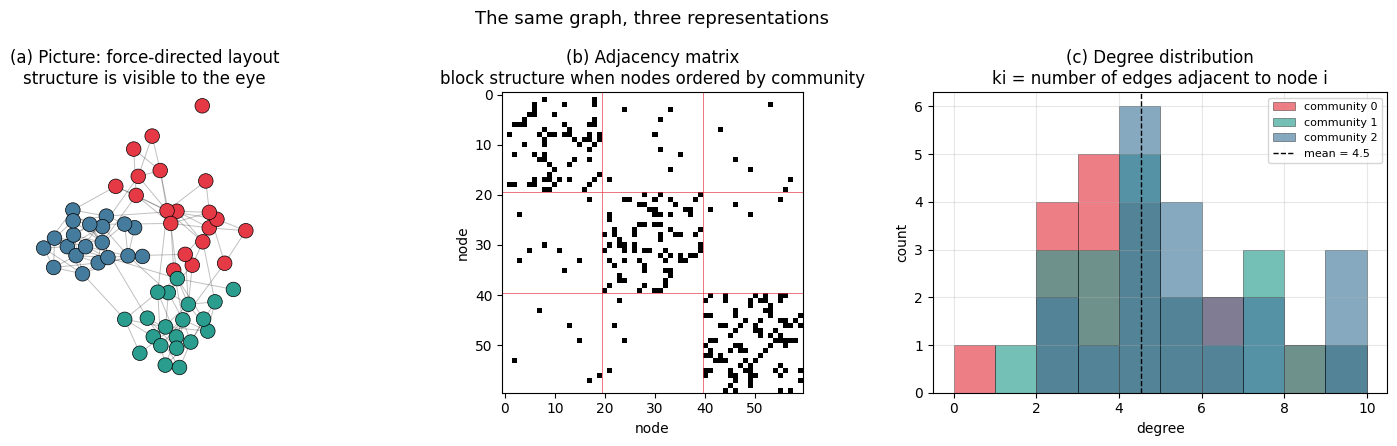

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) force-directed layout
pos = nx.spring_layout(G, seed=0, k=0.5, iterations=80)
ax = axes[0]
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.7)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_color,
                       node_size=110, edgecolors='black', linewidths=0.5)
ax.set_title("(a) Picture: force-directed layout\nstructure is visible to the eye")
ax.set_axis_off(); ax.set_aspect('equal')

# (b) adjacency matrix, ordered by community
order = np.argsort(community, kind='stable')
A = nx.to_numpy_array(G)[order][:, order]
ax = axes[1]
ax.imshow(A, cmap='Greys', interpolation='nearest', aspect='equal')
boundaries = np.cumsum([NODES_PER_COMM] * N_COMMUNITIES)[:-1]
for b in boundaries:
    ax.axhline(b - 0.5, color=COMMUNITY_COLORS[0], lw=0.7, alpha=0.7)
    ax.axvline(b - 0.5, color=COMMUNITY_COLORS[0], lw=0.7, alpha=0.7)
ax.set_title("(b) Adjacency matrix\nblock structure when nodes ordered by community")
ax.set_xlabel("node"); ax.set_ylabel("node")

# (c) degree distribution
degrees = np.array([d for _, d in G.degree()])
ax = axes[2]
for c in range(N_COMMUNITIES):
    ax.hist(degrees[community == c], bins=range(0, degrees.max() + 2),
            alpha=0.65, color=COMMUNITY_COLORS[c],
            edgecolor='black', linewidth=0.4,
            label=f'community {c}')
ax.axvline(degrees.mean(), color='black', lw=1, linestyle='--',
           label=f'mean = {degrees.mean():.1f}')
ax.set_title("(c) Degree distribution\nki = number of edges adjacent to node i")
ax.set_xlabel("degree"); ax.set_ylabel("count")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle("The same graph, three representations", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Random walks: the "sentences" for skip-gram

A random walk wanders the graph one neighbour at a time. Within a community, walks **stay in the community** for many steps (high internal connectivity), occasionally crossing a bridge edge to another community. So the *co-occurrence statistics* of a walk reveal community structure: nodes from the same community appear together inside the same walk window much more often than nodes from different communities.

We generate `walks_per_node` walks starting from each node, each of length `walk_length`. Then we slide a window of size `W` over each walk and emit `(target, context)` pairs — exactly like word2vec skip-gram, but on graph walks instead of natural-language sentences.

In [4]:
def random_walks(G, walks_per_node=10, walk_length=20, seed=0):
    rng = np.random.default_rng(seed)
    walks = []
    nodes = list(G.nodes())
    for _ in range(walks_per_node):
        rng.shuffle(nodes)
        for v in nodes:
            walk = [v]
            for _ in range(walk_length - 1):
                neighbours = list(G.neighbors(walk[-1]))
                if not neighbours:
                    break
                walk.append(int(rng.choice(neighbours)))
            walks.append(walk)
    return walks

walks = random_walks(G)
print(f"Generated {len(walks)} random walks of length up to 20")
print(f"Sample walk: {walks[0]}")

# slide a window of size W to build (target, context) pairs
W = 3
pairs = []
for walk in walks:
    for i, target in enumerate(walk):
        lo, hi = max(0, i - W), min(len(walk), i + W + 1)
        for j in range(lo, hi):
            if i != j:
                pairs.append((target, walk[j]))
pairs = np.array(pairs, dtype=np.int64)
print(f"{len(pairs):,} (target, context) pairs")

target = torch.tensor(pairs[:, 0], dtype=torch.long)
context = torch.tensor(pairs[:, 1], dtype=torch.long)

Generated 600 random walks of length up to 20
Sample walk: [16, 9, 17, 57, 17, 6, 17, 9, 16, 9, 19, 9, 19, 56, 49, 41, 52, 40, 52, 41]
63,720 (target, context) pairs


## 4. Skip-gram with negative sampling

One embedding table for the nodes, dot product as similarity score. For each `(target, context)` pair we want $\sigma(\mathbf{e}_t \cdot \mathbf{e}_c)$ to be large; for `K_NEG` randomly sampled "non-context" negatives we want $\sigma(-\mathbf{e}_t \cdot \mathbf{e}_n)$ to be large. The loss is the negative log-likelihood of those Bernoullis.

$$\mathcal{L} = -\,\mathbb{E}\!\left[\,\log\sigma(\mathbf{e}_t \cdot \mathbf{e}_c) + \sum_{n \sim \text{neg}} \log\sigma(-\mathbf{e}_t \cdot \mathbf{e}_n)\,\right]$$

In [8]:
DIM = 2          # 2D so we can plot directly
# Limitiamo le dimensioni a 2 per poter disegnare i nodi su uno schermo X,Y.
# In un sistema vero come Netflix o Google, useresti 32, 64 o 128.

K_NEG = 5        # negatives per positive
# Per ogni nodo amico che vogliamo avvicinare, estrarremo a sorte 5 nodi 
# "nemici" per allontanarli.

class NodeEmb(nn.Module):
    def __init__(self, n, d):
        super().__init__()
        # Creiamo un "taccuino" (Embedding Table). Ha 'n' righe (60 nodi) e 'd' colonne (2 dimensioni).
        # Questa tabella è il cervello della nostra rete neurale. 
        # Partirà con numeri a caso e si modificherà durante l'addestramento.
        self.E = nn.Embedding(n, d)
        
        # Inizializziamo i vettori con valori casuali molto piccoli (distribuzione normale)
        nn.init.normal_(self.E.weight, std=0.1)

    # La funzione 'forward' esegue i calcoli. Riceve:
    # - target: un lotto (Batch, B) di nodi bersaglio.
    # - context: i rispettivi B nodi amici (positivi).
    # - neg: B * K_NEG nodi nemici scelti a caso.
    def forward(self, target, context, neg):
        
        # 1. Estrarre i vettori (le coordinate X,Y) dalla tabella per i tre gruppi
        t = self.E(target)                                     # Forma del tensore: (B, d)
        c = self.E(context)                                    # Forma del tensore: (B, d)
        n = self.E(neg)                                        # Forma del tensore: (B, K, d)
        
        # 2. Il lato POSITIVO (Tiro alla fune: Avvicina)
        # Moltiplichiamo riga per riga i vettori Target e Context (prodotto scalare).
        # Vogliamo che questo numero (pos) cresca.
        pos = (t * c).sum(-1)                                  # Forma del tensore: (B,)
        
        # 3. Il lato NEGATIVO (Tiro alla fune: Allontana)
        # Moltiplichiamo il singolo vettore Target per i suoi K_NEG vettori Negativi associati.
        # Usa 'einsum' per fare un prodotto matriciale su tensori a più dimensioni.
        ng  = torch.einsum('bd,bkd->bk', t, n)                 # Forma del tensore: (B, K)
        
        # 4. Calcolo dell'ERRORE (Loss)
        # torch.nn.functional.logsigmoid calcola il logaritmo della probabilità.
        # Il segno '-' davanti a 'ng' dice alla rete di PUNIRE la vicinanza coi nodi casuali.
        loss = -(torch.nn.functional.logsigmoid(pos).mean()
                 + torch.nn.functional.logsigmoid(-ng).mean())
        
        return loss

# Inizializziamo il modello passando i 60 nodi (N) e le 2 dimensioni (DIM)
model = NodeEmb(N, DIM)

# L'ottimizzatore Adam è il "meccanico" che andrà a modificare i numeri nella tabella 
# (i parametri) per abbassare l'errore.
opt = torch.optim.Adam(model.parameters(), lr=0.05)

ciao


## 5. Train, snapshotting embeddings

Same trick as the session 07 demo: capture the embedding tensor at epochs 0, 5, 25, 100, 300 so we can watch the geometry form.

In [7]:
SNAPSHOTS = [0, 5, 25, 100, 300]
N_EPOCHS = SNAPSHOTS[-1] + 1

snaps = {}
losses = []
rng_neg = np.random.default_rng(1)
for epoch in range(N_EPOCHS):
    if epoch in SNAPSHOTS:
        snaps[epoch] = model.E.weight.detach().numpy().copy()
    neg = torch.tensor(rng_neg.integers(0, N, size=(len(pairs), K_NEG)),
                       dtype=torch.long)
    loss = model(target, context, neg)
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())
print(f"final skip-gram loss = {losses[-1]:.3f}")

ciao
final skip-gram loss = 1.140


## 6. Watch the embeddings move

**What to look for:**

- Epoch 0: random noise around the origin.
- Epoch 5: things start to spread.
- Epoch 25: three clusters appear, arranged in a rough triangle around the origin (3 directions, 120° apart — the natural arrangement of 3 unit vectors in 2D).
- Epoch 100 / 300: clean separation. A few "boundary" nodes — those with many cross-community edges — sit between two clusters.

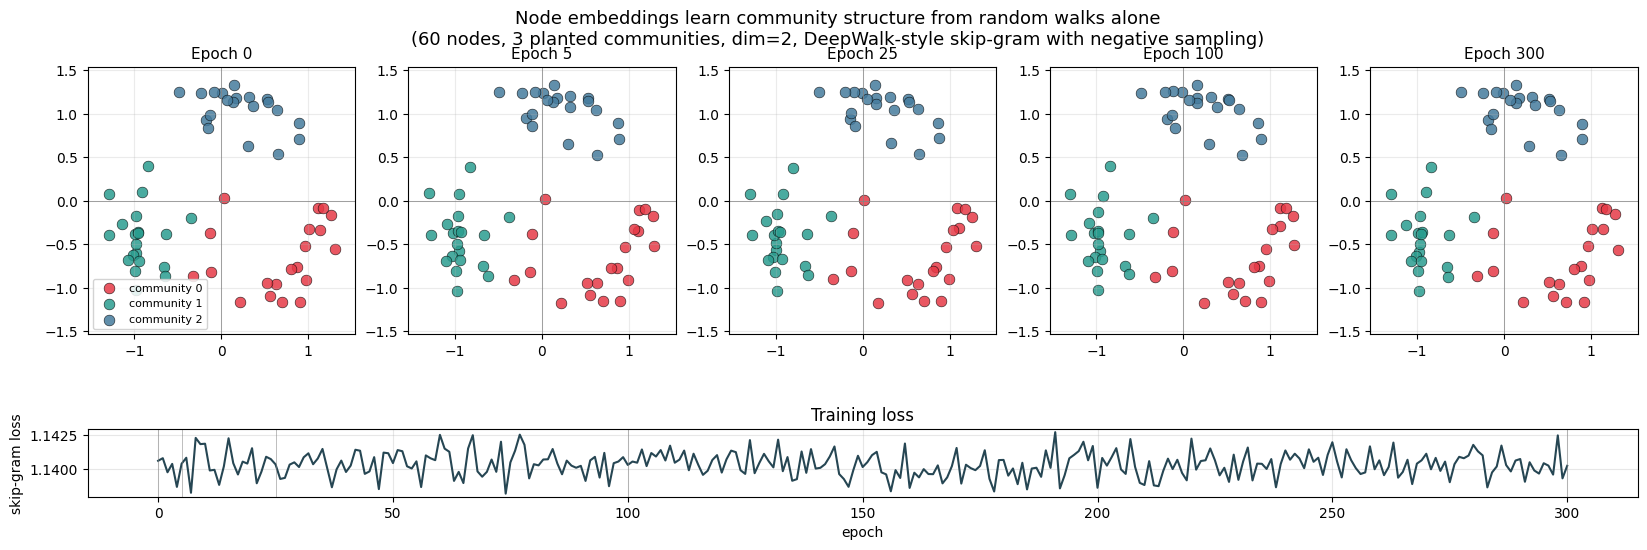

In [10]:
fig = plt.figure(figsize=(4 * len(SNAPSHOTS), 5.6))
gs = fig.add_gridspec(2, len(SNAPSHOTS), height_ratios=[4, 1], hspace=0.55)

all_pts = np.vstack(list(snaps.values()))
lim = max(abs(all_pts.min()), abs(all_pts.max())) * 1.15

for col, ep in enumerate(SNAPSHOTS):
    ax = fig.add_subplot(gs[0, col])
    E = snaps[ep]
    for c in range(N_COMMUNITIES):
        mask = community == c
        ax.scatter(E[mask, 0], E[mask, 1],
                   c=COMMUNITY_COLORS[c], s=60,
                   edgecolor='black', linewidth=0.4, alpha=0.85,
                   label=f'community {c}' if col == 0 else None)
    ax.set_title(f"Epoch {ep}", fontsize=11)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.grid(alpha=0.25)
    ax.axhline(0, c='gray', lw=0.5); ax.axvline(0, c='gray', lw=0.5)
    if col == 0:
        ax.legend(fontsize=8, loc='lower left', framealpha=0.85)

ax_loss = fig.add_subplot(gs[1, :])
ax_loss.plot(losses, c='#264653')
for ep in SNAPSHOTS:
    ax_loss.axvline(ep, c='gray', lw=0.6, alpha=0.6)
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("skip-gram loss")
ax_loss.set_title("Training loss"); ax_loss.grid(alpha=0.3)

fig.suptitle(
    "Node embeddings learn community structure from random walks alone\n"
    f"({N} nodes, {N_COMMUNITIES} planted communities, dim={DIM}, "
    "DeepWalk-style skip-gram with negative sampling)",
    fontsize=13,
)
plt.show()

## 7. Sanity check: predict community from embedding alone

Use the learned embeddings as features and predict each node's community by looking at the community of its **single nearest neighbour in embedding space**. The model never saw the community labels — yet this should be close to perfect.

In [11]:
E_final = snaps[SNAPSHOTS[-1]]
En = E_final / (np.linalg.norm(E_final, axis=1, keepdims=True) + 1e-9)
sim = En @ En.T
np.fill_diagonal(sim, -np.inf)
nearest = sim.argmax(axis=1)
acc = (community[nearest] == community).mean()
print(f"1-NN community-prediction accuracy from embeddings: {acc:.1%}")

# Show the few mistakes (misclassified nodes) — typically nodes with many cross-community edges.
mistakes = np.where(community[nearest] != community)[0]
print(f"\nMistakes ({len(mistakes)}):")
for m in mistakes:
    cross_edges = sum(1 for n in G.neighbors(m) if community[n] != community[m])
    total_edges = G.degree(m)
    print(f"  node {m}: true community {community[m]}, predicted {community[nearest[m]]}, "
          f"{cross_edges}/{total_edges} cross-community edges")

1-NN community-prediction accuracy from embeddings: 96.7%

Mistakes (2):
  node 0: true community 0, predicted 2, 0/0 cross-community edges
  node 46: true community 2, predicted 0, 2/9 cross-community edges


## 8. Discussion

### Why does this work at all?

Within-community edges are roughly **13× more common** than cross-community edges in our graph (`P_IN / P_OUT = 0.20 / 0.015 ≈ 13`). A random walk that starts inside community 0 will, on average, spend most of its 20 steps inside community 0 — bouncing around between its members — before occasionally crossing a bridge edge.

So when we slide a context window over the walk, the `(target, context)` pairs are dominated by **same-community pairs**. Skip-gram pulls those nodes together in vector space and pushes random negatives apart, and the geometry that minimises this loss is exactly: one direction per community.

### Why a triangle in 2D?

Same dimensionality story as session 07. Three communities want three mutually-distant directions; the most-distant arrangement of 3 unit vectors in 2D is at 120° apart — an equilateral triangle. With `DIM = 2` and `N_COMMUNITIES = 3` the model can hit the optimum perfectly. With more communities than dimensions it has to compromise, just like the 5-genre pentagon.

### Why are some nodes "between" two clusters?

Look at the mistakes printed above: every misclassified node has an unusually high fraction of cross-community edges. From the random walk's perspective, those nodes co-occur with members of multiple communities, so the embedding ends up reflecting that mixed neighbourhood. This is a feature, not a bug — same logic as the blended-taste users in session 07.

### Connection to user/movie embeddings

Both demos train a single embedding table and use a dot-product similarity score. The only thing that changes is **how we generate the (target, context) pairs**:

- Session 07: `(user_id, movie_id, rating)` — pairs from explicit feedback.
- Session 08: `(node_a, node_b)` — pairs from sliding a window over random walks.

Different data source, same recipe, same emergent geometry. That is why representation learning generalises so well across domains.

### Limits of shallow node embeddings

What this method **cannot** do:

- **Inductive prediction.** A new node added to the graph has no embedding — we'd have to retrain to get one. Graph neural networks (GraphSAGE, GAT) fix this by computing embeddings as functions of node *features* and neighbourhood, not as a lookup table.
- **Use node features.** We treated nodes as opaque IDs. If nodes carry attributes (text, tags, profile data), shallow embeddings ignore them. GNNs again.
- **Heterogeneous graphs.** Real graphs have multiple node types (users, items, tags) and multiple edge types. Recipes like `metapath2vec` extend random walks to typed walks; full heterogeneous GNNs go further.

Those are the natural sequel — coming up in session 10 (Graph Neural Networks).